## Anatomy, CTGF-tdt Cortical distribution
By Debora Masini, 2023

This notebook is used to plot the anteroposterior and mediolateral distribution of Cortical CTGF-tdt neurons.

In [ ]:
import numpy as np
import pandas as pd

import os
import glob

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Define the path to the directory containing the files
path = r"...\QuPath_CTGF_cell count" # these are files such as 4972_sagg_1_Detections.txt (mouseID_SliceMethod_ImageID)....one fiel per image. Contains cortical TdT ROIs found.
files = glob.glob(os.path.join(path, '*Detections.txt')) # Use glob to list all files ending with 'Detections.txt'

full_df = pd.DataFrame()

# Loop through the list of files and read each one into a DataFrame, then append it 
for file in files:
    temp_df = pd.read_csv(file, sep='\t', on_bad_lines='skip')
    full_df = pd.concat([full_df, temp_df], ignore_index=True)


num_rows = len(full_df)
print("this is the number of CTGF neurons counted:")
print(num_rows)
# expected rows 128292, subtract header row...report: 128 291 cortical Ctgf cortical neurons counted

In [ ]:
# Creating a density heatmap using seaborn's kdeplot
plt.figure(figsize=(10, 6))
sns.kdeplot(x=full_df['Centroid X µm'], y=full_df['Centroid Y µm'], cmap="Reds", fill=True)
plt.title('Density Heatmap of Cortical CTGF positions, Kernel Density Estimation with Gaussian curve')
plt.xlabel('Centroid X µm')
plt.ylabel('Centroid Y µm')
plt.grid(False)
plt.savefig(r"...\Cortical_CTGFlocation_heatmap.svg", format='svg')
plt.show()

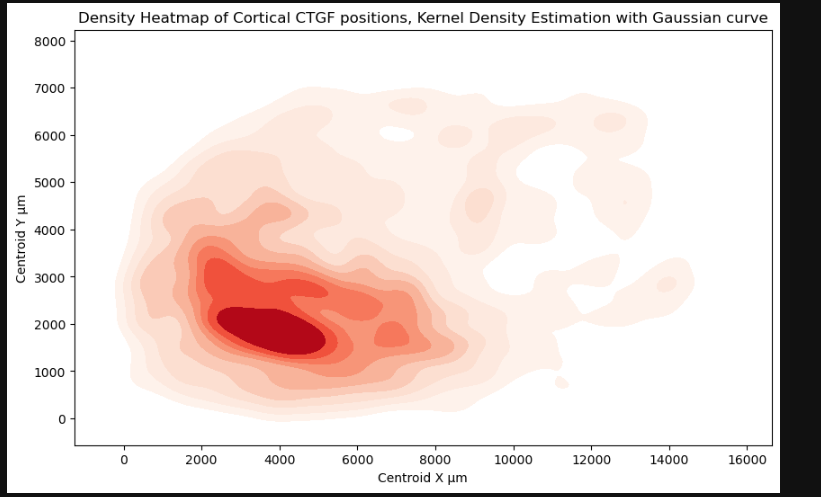

### Density values calculated by the kernel density estimation (KDE) process. A visual representation of where points are most densely clustered and how they spread out across the x and y dimensions.

 - The KDE process places a smooth "bump" at the location of each data point. -> Kernel type: Gaussian kernel is the default.
 - It then adds up all these bumps to create a smooth surface.
 - The height of this surface at any given point represents the estimated density of data points in that area.
 - The density values on the colorbar indicate the height of this surface, with higher values indicating areas where the surface (and thus the concentration of data points) is higher.
 - https://seaborn.pydata.org/generated/seaborn.kdeplot.html

In [ ]:
# Proportional embedding of image coordinate system into approximate Paxinos atlas dimensions
# via linear rescaling from current coordinate space to corrected anatomical space for Paxinos

# scale factors
sx = 4.25 / 8000  ### Paxinos approximate maximal mediolateral position is 4.25mm (0 to 4.25mm from bregma)
sy = 8.25 / 16000   ### Paxinos approximate anteroposterior position is  8.25mm (cortex from 3.20 to -5.07mm from bregma, =around 8.25mm)

# Spatial coordinates linearly rescaled to approximate anatomical dimensions based on Paxinos
#...converting microns to millimeters and compressing into Paxinos cortical bounds in one step

filtered_df = full_df.copy()
filtered_df['Centroid X mm'] = filtered_df['Centroid X µm'] * sx
filtered_df['Centroid Y mm'] = filtered_df['Centroid Y µm'] * sy

path = r"...\filtered_df.csv"  # save filtered
filtered_df.to_csv(path, index=False)

In [ ]:
# script end